In [ ]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/Project Warm-up 02/ColabData/ecommerce.csv'

# Dataset này hay không phải UTF-8
df = pd.read_csv(path, encoding='latin1')

df.shape, df.head()

((541909, 8),
   InvoiceNo StockCode                          Description  Quantity  \
 0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
 1    536365     71053                  WHITE METAL LANTERN         6   
 2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
 3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
 4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
 
       InvoiceDate  UnitPrice  CustomerID         Country  
 0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
 1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
 2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
 3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
 4  12/1/2010 8:26       3.39     17850.0  United Kingdom  )

Data set có 541.909 dòng, 8 cột.  
Mỗi hóa đơn có nhiều sản phầm, một sản phẩm có thể nằm ở trong nhiều hóa đơn

In [ ]:
df.info()
df.isna().mean().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,0
CustomerID,0.249267
Description,0.002683
StockCode,0.000000
InvoiceNo,0.000000
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
Country,0.000000


- CustomerID 406829 non-null ⇒ chỉ 406,829 dòng có CustomerID, còn lại bị thiếu.
- Description 540455 non-null ⇒ thiếu mô tả ở một ít dòng.
- InvoiceDate đang là object ⇒ nó đang là chuỗi, chưa phải datetime ⇒phải chuyển sang datetime để tính Recency.
- CustomerID là float64 ⇒ vì cột này có missing nên pandas dùng float.
- InvoiceNo, StockCode, Description, Country là object (chuỗi).

In [ ]:
df = df.copy()

df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [ ]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

giai đoạn: 01/12/2010 → 09/12/2011

In [ ]:
import pandas as pd
df_clean = df.copy()
# đảm bảo đúng kiểu
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')

# 1) bỏ thiếu CustomerID (bắt buộc cho RFM)
df_clean = df_clean.dropna(subset=['CustomerID', 'InvoiceDate'])

# 2) bỏ hoá đơn huỷ (InvoiceNo bắt đầu 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C', na=False)]

# 3) bỏ trả hàng/lỗi
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 4) tạo doanh thu
df_clean['Amount'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean = df_clean[df_clean['Amount'] > 0]

print("Before:", df.shape)
print("After cleaning:", df_clean.shape)

Before: (541909, 8)
After cleaning: (397884, 9)


- Before: (541,909 dòng, 8 cột)
- After cleaning: (397,884 dòng, 9 cột), loại bỏ tầm 144000 dòng, thiếu CustomerId, hóa đơn hủy ( bắt đầu bằng C), Quantity <= 0, UnitPrice <= 0, Ammount <= 0. Thêm một cột vì Amount = Quantity * UnitPrice

In [ ]:
analysis_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
analysis_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
clean_path = '/content/drive/MyDrive/Colab Notebooks/Project Warm-up 02/ColabData/online_retail_clean.csv'
df_clean.to_csv(clean_path, index=False)
clean_path

'/content/drive/MyDrive/Colab Notebooks/Project Warm-up 02/ColabData/online_retail_clean.csv'

In [ ]:
rfm = (
    df_clean.groupby('CustomerID')
    .agg(
        Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('Amount', 'sum')
    )
    .reset_index()
)

rfm.head(), rfm.shape

(   CustomerID  Recency  Frequency  Monetary
 0     12346.0      326          1  77183.60
 1     12347.0        2          7   4310.00
 2     12348.0       75          4   1797.24
 3     12349.0       19          1   1757.55
 4     12350.0      310          1    334.40,
 (4338, 4))

- Recency = số ngày từ lần mua gần nhất đến analysis_date (càng nhỏ càng “mới”)
- Frequency = số hóa đơn mua (InvoiceNo unique) (càng lớn càng “mua nhiều lần”)
- Monetary = tổng chi tiêu (Amount sum) (càng lớn càng “chi nhiều”)

In [ ]:
rfm[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


- min = 1 ngày: có khách mua rất sát ngày chốt dữ liệu.
- median (50%) = 51 ngày: một khách điển hình mua lần gần nhất cách đây ~51 ngày.
- 75% = 142 ngày: 75% khách có lần mua gần nhất trong vòng 142 ngày.
- max = 374 ngày: có khách “rất lâu không quay lại”.
- mean = 92.5 ngày, std = 100 ngày: phân tán lớn, có nhiều khách đã lâu không mua

In [ ]:
import pandas as pd

rfm_scored = rfm.copy()

rfm_scored['R_score'] = pd.qcut(rfm_scored['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm_scored['F_score'] = pd.qcut(rfm_scored['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm_scored['M_score'] = pd.qcut(rfm_scored['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

rfm_scored['RFM_Score'] = (
    rfm_scored['R_score'].astype(str) +
    rfm_scored['F_score'].astype(str) +
    rfm_scored['M_score'].astype(str)
)

rfm_scored[['CustomerID','Recency','Frequency','Monetary','R_score','F_score','M_score','RFM_Score']].head(10)

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,244
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112
5,12352.0,36,8,2506.04,3,5,5,355
6,12353.0,204,1,89.00,1,1,1,111
7,12354.0,232,1,1079.40,1,1,4,114
8,12355.0,214,1,459.40,1,1,2,112
9,12356.0,23,3,2811.43,4,3,5,435


- R_score: 1–5 (5 là mua gần đây nhất, 1 là lâu rồi không mua)
- F_score: 1–5 (5 là mua nhiều lần nhất)
- M_score: 1–5 (5 là chi tiêu nhiều nhất)
- RFM_Score là chuỗi ghép R_scoreF_scoreM_score (ví dụ 555 là nhóm “đỉnh” ở cả 3 tiêu chí)

In [ ]:
rfm_scored['RFM_Score'].value_counts().head(15)

,count
RFM_Score,
555,348
111,183
455,178
121,153
112,128
444,122
122,92
544,88
233,85


- 555 = 348 khách ⇒ đây là nhóm tốt nhất (mua gần đây + mua nhiều + chi nhiều)
- 111 = 183 khách ⇒ nhóm kém nhất (lâu không mua + mua ít + chi ít)
- Các nhóm như 455, 544, 554, 444 xuất hiện nhiều

In [ ]:

def segmenting_rfm(df):
    # 1. Champions: Mua rất gần đây (R=5) và mua cực kỳ thường xuyên (F=5)
    if (df['R_score'] == 5) and (df['F_score'] == 5):
        return 'Champions'

    # 2. Loyal Customers: Mua thường xuyên (F >= 4), phong độ ổn định
    elif (df['F_score'] >= 4):
        return 'Loyal Customers'

    # 3. New Customers: Mới mua gần đây (R=5) nhưng chưa mua nhiều (F=1,2)
    elif (df['R_score'] == 5) and (df['F_score'] <= 2):
        return 'New Customers'

    # 4. At Risk: Từng mua khá (F >= 3) nhưng đã quá lâu không quay lại (R <= 2)
    elif (df['R_score'] <= 2) and (df['F_score'] >= 3):
        return 'At Risk'

    # 5. Lost Customers: Mua ít, chi ít và đã biến mất từ lâu (R thấp, F thấp)
    else:
        return 'Lost Customers'

rfm_scored['Segment'] = rfm_scored.apply(segmenting_rfm, axis=1)

print("KẾT QUẢ PHÂN NHÓM MỚI:")
print("-" * 30)
counts = rfm_scored['Segment'].value_counts()
percent = rfm_scored['Segment'].value_counts(normalize=True) * 100

for label in counts.index:
    print(f"{label}: {counts[label]} khách hàng ({percent[label]:.1f}%)")

rfm_scored[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']].head()

KẾT QUẢ PHÂN NHÓM MỚI:
------------------------------
Lost Customers: 2136 khách hàng (49.2%)
Loyal Customers: 1296 khách hàng (29.9%)
Champions: 439 khách hàng (10.1%)
At Risk: 368 khách hàng (8.5%)
New Customers: 99 khách hàng (2.3%)


,CustomerID,Recency,Frequency,Monetary,Segment
0,12346.0,326,1,77183.60,Lost Customers
1,12347.0,2,7,4310.00,Champions
2,12348.0,75,4,1797.24,Loyal Customers
3,12349.0,19,1,1757.55,Lost Customers
4,12350.0,310,1,334.40,Lost Customers


In [ ]:
out_path = '/content/drive/MyDrive/Colab Notebooks/Project Warm-up 02/ColabData/rfm_labeled.csv'

rfm_scored.to_csv(out_path, index=False)

# 3. In ra để xác nhận cột đã tồn tại trong file lưu
print("Cột có trong file vừa lưu:", rfm_scored.columns.tolist())
print(f"Đã lưu thành công tại: {out_path}")

Cột có trong file vừa lưu: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'Segment']
Đã lưu thành công tại: /content/drive/MyDrive/Colab Notebooks/Project Warm-up 02/ColabData/rfm_labeled.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

path = '/content/drive/MyDrive/Colab Notebooks/Project Warm-up 02/ColabData/rfm_labeled.csv'
df_rfm = pd.read_csv(path)

X = df_rfm[['Recency', 'Frequency', 'Monetary']]
y = df_rfm['Segment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print(f"- Tập huấn luyện: {X_train.shape[0]} khách hàng")
print(f"- Tập kiểm tra: {X_test.shape[0]} khách hàng")

- Tập huấn luyện: 3904 khách hàng
- Tập kiểm tra: 434 khách hàng


- Lấy những kết quả về Recency, Frequency, Monetary làm máy lọc, kết quả đầu ra là những nhãn At Risk, Champions, ...
- Huấn luyện 90% dữ liệu, 10% dử liệu để test, random_state để tránh việc mô hình random sau mỗi lần chạy

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

        At Risk       0.67      0.73      0.70        45
      Champions       1.00      1.00      1.00        44
 Lost Customers       0.91      0.87      0.89       210
Loyal Customers       0.86      0.90      0.88       126
  New Customers       0.89      0.89      0.89         9

       accuracy                           0.88       434
      macro avg       0.87      0.88      0.87       434
   weighted avg       0.88      0.88      0.88       434



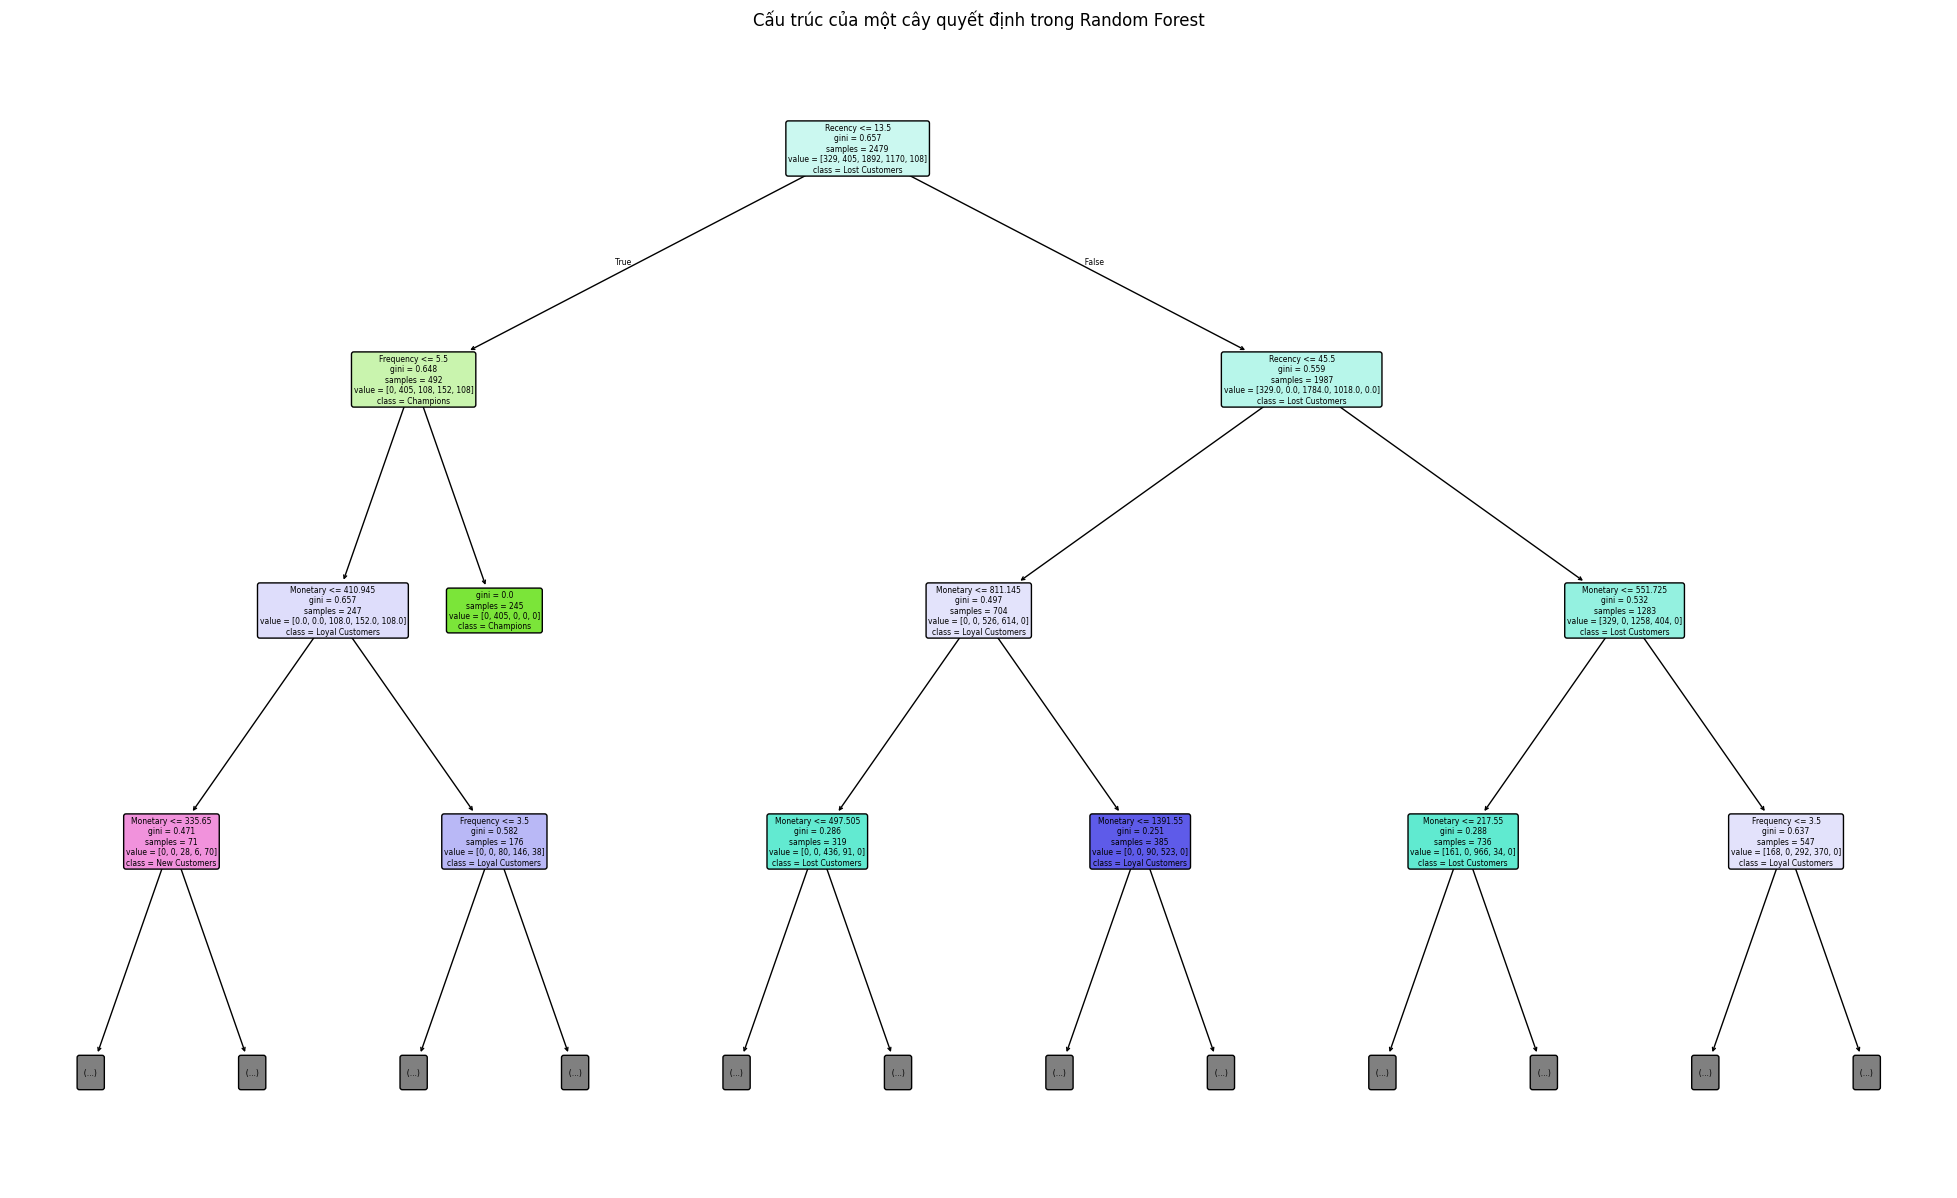

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
chosen_tree = rf_model.estimators_[0]
plt.figure(figsize=(25, 15))
plot_tree(chosen_tree, feature_names=['Recency', 'Frequency', 'Monetary'], class_names=rf_model.classes_,
          filled=True,
          rounded=True,
          max_depth=3)
plt.title("Cấu trúc của một cây quyết định trong Random Forest")
plt.show()

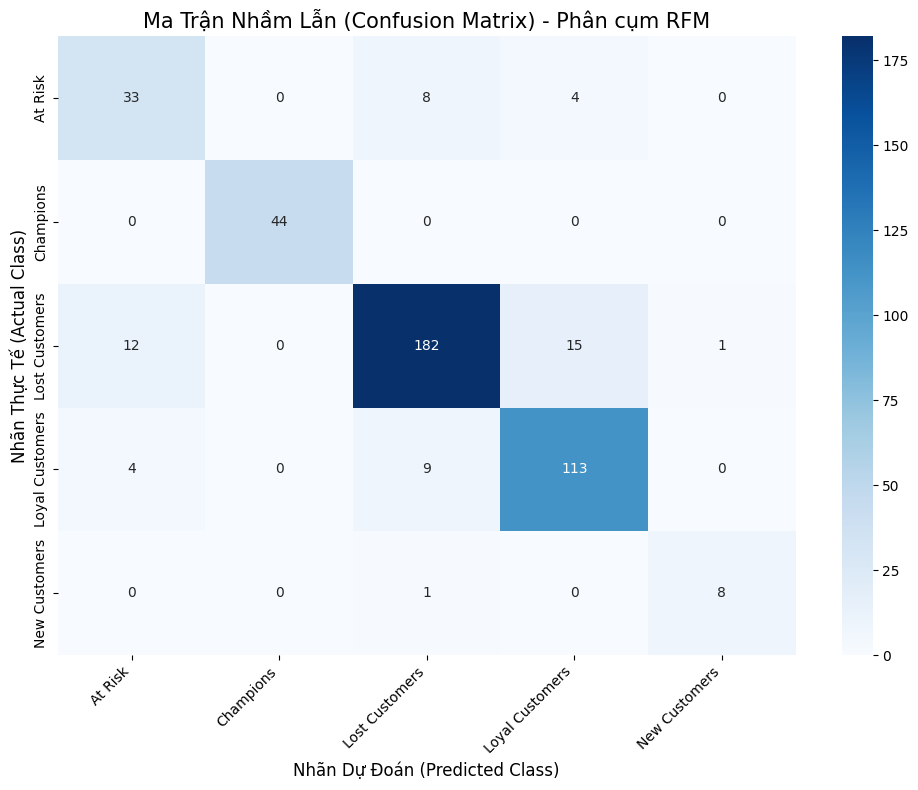

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# Thiết lập kích thước khung hình
plt.figure(figsize=(10, 8))

# Vẽ heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

# Thêm tiêu đề và nhãn cho các trục
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) - Phân cụm RFM', fontsize=15)
plt.xlabel('Nhãn Dự Đoán (Predicted Class)', fontsize=12)
plt.ylabel('Nhãn Thực Tế (Actual Class)', fontsize=12)

plt.xticks(rotation=45, ha='right') # Xoay nhãn trục X cho dễ đọc
plt.tight_layout()
plt.show()

**Tối ưu hóa**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Khởi tạo mô hình cơ sở với class_weight='balanced'
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Mở rộng không gian tham số (Rộng hơn và chi tiết hơn)
param_grid = {
    'n_estimators': [100, 200, 300, 500],  # Thử nghiệm lên tới 500 cây quyết định
    'max_depth': [10, 15, 20, None],       # Giới hạn độ sâu để tránh học vẹt
    'min_samples_split': [2, 5, 10],       # Điều kiện khắt khe hơn để tách nhánh
    'min_samples_leaf': [1, 2]             # Số mẫu tối thiểu ở nút lá cuối cùng
}

# 3. Khởi tạo GridSearchCV với tiêu chí chấm điểm khắt khe
grid_search_max = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', # QUAN TRỌNG: Ép mô hình tối ưu điểm trung bình của tất cả các nhóm
    n_jobs=-1,          # Dùng tối đa CPU
    verbose=2
)

grid_search_max.fit(X_train, y_train)

# 5. Kết quả
print("\nBỘ THAM SỐ HOÀN HẢO NHẤT:", grid_search_max.best_params_)

# 6. Dự đoán với mô hình xịn nhất
best_rf_ultimate = grid_search_max.best_estimator_
y_pred_ultimate = best_rf_ultimate.predict(X_test)

# 7. Đánh giá cuối cùng
print("\nBÁO CÁO PHÂN LOẠI (TỐI ƯU HÓA TUYỆT ĐỐI):")
print(classification_report(y_test, y_pred_ultimate))

Fitting 5 folds for each of 96 candidates, totalling 480 fits

BỘ THAM SỐ HOÀN HẢO NHẤT: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

BÁO CÁO PHÂN LOẠI (TỐI ƯU HÓA TUYỆT ĐỐI):
                 precision    recall  f1-score   support

        At Risk       0.68      1.00      0.81        45
      Champions       1.00      1.00      1.00        44
 Lost Customers       0.98      0.85      0.91       210
Loyal Customers       0.89      0.92      0.90       126
  New Customers       0.73      0.89      0.80         9

       accuracy                           0.90       434
      macro avg       0.85      0.93      0.88       434
   weighted avg       0.92      0.90      0.90       434



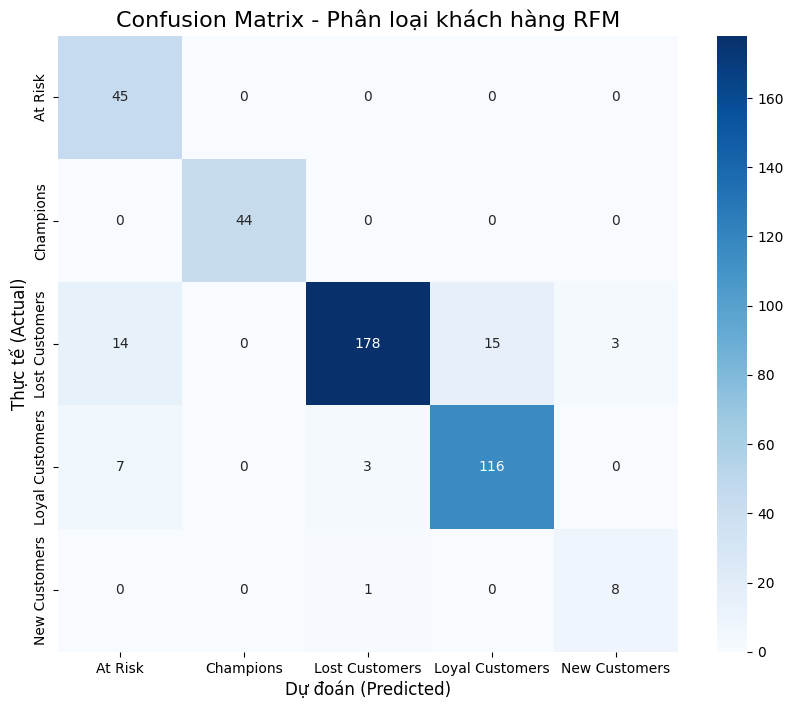

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Tạo ma trận nhầm lẫn từ dự đoán của mô hình tốt nhất
cm = confusion_matrix(y_test, y_pred_ultimate)

# 2. Lấy danh sách tên các nhóm (Segment names) để hiển thị trên trục
# Lưu ý: Sắp xếp theo thứ tự nhãn mà mô hình đã học
labels = sorted(rfm_scored['Segment'].unique())

# 3. Vẽ biểu đồ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

# 4. Thêm các thông tin mô tả
plt.title('Confusion Matrix - Phân loại khách hàng RFM', fontsize=16)
plt.ylabel('Thực tế (Actual)', fontsize=12)
plt.xlabel('Dự đoán (Predicted)', fontsize=12)
plt.show()

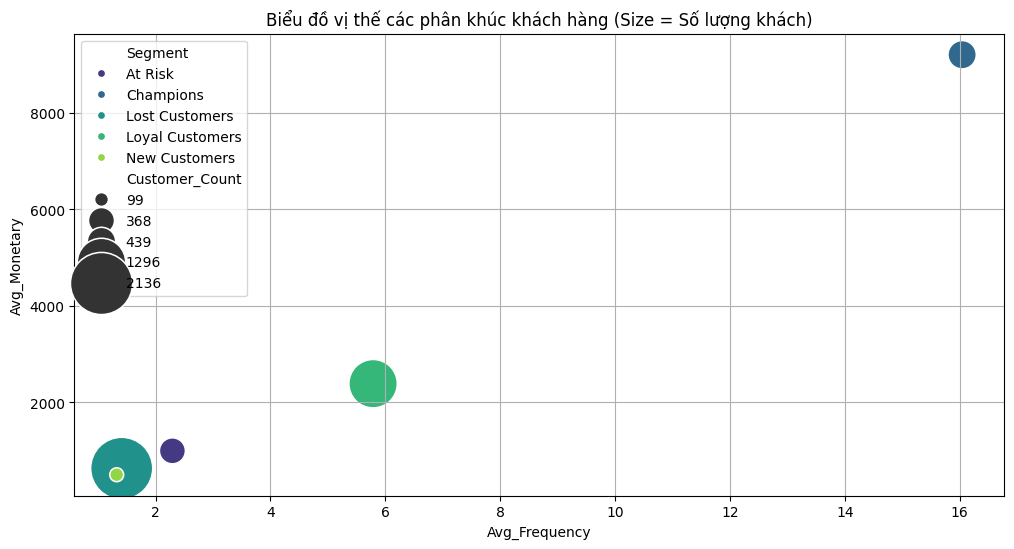

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share (%)
1,Champions,439,5.699317,16.043280,9204.021982,4040565.650,45.341496
3,Loyal Customers,1296,51.383488,5.787809,2389.083496,3096252.211,34.744815
2,Lost Customers,2136,126.894663,1.410581,635.533606,1357499.782,15.233281
0,At Risk,368,164.627717,2.293478,998.083046,367294.561,4.121622
4,New Customers,99,7.050505,1.323232,502.986869,49795.700,0.558786


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gom nhóm để tính toán các chỉ số trung bình và tổng
segment_analysis = rfm_scored.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).reset_index()

# Đổi tên cột cho dễ đọc
segment_analysis.columns = ['Segment', 'Customer_Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue']

# Tính % đóng góp doanh thu
total_rev = segment_analysis['Total_Revenue'].sum()
segment_analysis['Revenue_Share (%)'] = (segment_analysis['Total_Revenue'] / total_rev) * 100

# Trực quan hóa mối tương quan giữa các nhóm
plt.figure(figsize=(12, 6))
sns.scatterplot(data=segment_analysis, x='Avg_Frequency', y='Avg_Monetary',
                size='Customer_Count', hue='Segment', sizes=(100, 2000), palette='viridis')
plt.title('Biểu đồ vị thế các phân khúc khách hàng (Size = Số lượng khách)')
plt.grid(True)
plt.show()

display(segment_analysis.sort_values(by='Total_Revenue', ascending=False))

/tmp/ipykernel_3319/4200771297.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


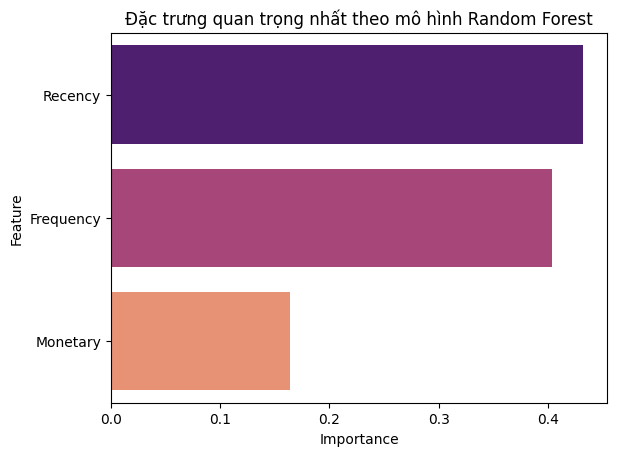

In [ ]:
# Trích xuất độ quan trọng của đặc trưng từ mô hình bạn đã huấn luyện
import pandas as pd

importances = best_rf_ultimate.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': ['Recency', 'Frequency', 'Monetary'],
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Đặc trưng quan trọng nhất theo mô hình Random Forest')
plt.show()

In [ ]:
# Lưu mô hình Random Forest đã tối ưu để deploy
import joblib

joblib.dump(best_rf_ultimate, 'best_rf_ultimate.pkl')
print('Đã lưu model: best_rf_ultimate.pkl')

# (Tuỳ chọn) lưu thêm dữ liệu test để demo nhanh
joblib.dump({'X_test': X_test, 'y_test': y_test}, 'rf_test_sample.pkl')
print('Đã lưu sample test: rf_test_sample.pkl')
